In [1]:
# Loading necessary modules. Always do so at the beginning.
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from os import fspath
%matplotlib inline
!pip install seaborn
import seaborn as sns
import math

In [2]:
!pip install MDAnalysis
import MDAnalysis as mda
mda.__version__

'2.9.0'

In [3]:
!pip install nglview
import nglview

In [4]:
simdir = Path('/home/marte/Master_degree/Computational_Biophysics/Biophysics backup/')
PSF = simdir / 'Alpha_final_noW.gro'
eqxtc = simdir / 'Alpha_protein_only.xtc'
PDB = simdir / 'Alpha_fold_barnase.pdb'
C_PDB = simdir / 'Barnese_ala.pdb'
C_PSF = simdir / 'Chimera_final_noW.gro'
eqxtc_C = simdir / 'md_protein_only.xtc'
WT_PSF = simdir / 'wt_protein_only.gro'
eqxtc_WT = simdir / 'wt_protein_only.xtc'

In [5]:
u = mda.Universe(str(PSF), str(eqxtc))

In [6]:
u_C = mda.Universe(str(C_PSF), str(eqxtc_C))

In [7]:
u_WT =  mda.Universe(str(WT_PSF), str(eqxtc_WT))
u_WT_new = u_WT.copy()

In [8]:
u_new = u.copy()

In [9]:
u_C_new = u_C.copy()

In [10]:
from MDAnalysis.analysis.rms import rmsd

In [17]:
len(u.trajectory[::10])

5001

In [11]:
#Alpha vs Chimera
red_factor = 1 # no reduction performed
rmsd_map_A_C = [rmsd(u.select_atoms('name CA').positions, u_C.select_atoms('name CA').positions, center=True, superposition=True) for ts in u.trajectory[::10] for ts_one in u_C.trajectory[::10]]

In [ ]:
#Alpha vs alpha
red_factor = 1 # no reduction performed
rmsd_map = [rmsd(u.select_atoms('name CA').positions, u_new.select_atoms('name CA').positions, center=True, superposition=True) for ts in u.trajectory[::10] for ts_one in u_new.trajectory[::10]]

In [ ]:
#Wild type vs Wild type
red_factor = 1 # no reduction performed
rmsd_map_WT = [rmsd(u_WT.select_atoms('name CA').positions, u_WT_new.select_atoms('name CA').positions, center=True, superposition=True) for ts in u_WT.trajectory[::10] for ts_one in u_WT_new.trajectory[::10]]

In [ ]:
#Chimera vs Chimera
red_factor = 1 # no reduction performed
rmsd_map_C_C = [rmsd(u_C.select_atoms('name CA').positions, u_C_new.select_atoms('name CA').positions, center=True, superposition=True) for ts in u_C.trajectory[::10] for ts_one in u_C_new.trajectory[::10]]

In [38]:
#Alpha vs wild type
red_factor = 1 # no reduction performed
rmsd_map_A_WT = [rmsd(u.select_atoms('name CA').positions, u_WT.select_atoms('name CA').positions, center=True, superposition=True) for ts in u.trajectory[::10] for ts_one in u_WT.trajectory[::10]]

In [41]:
#Chimera vs wild type
red_factor = 1 # no reduction performed
rmsd_map_C_WT = [rmsd(u_C.select_atoms('name CA').positions, u_WT.select_atoms('name CA').positions, center=True, superposition=True) for ts in u_C.trajectory[::10] for ts_one in u_WT.trajectory[::10]]

effective dimension is  1000


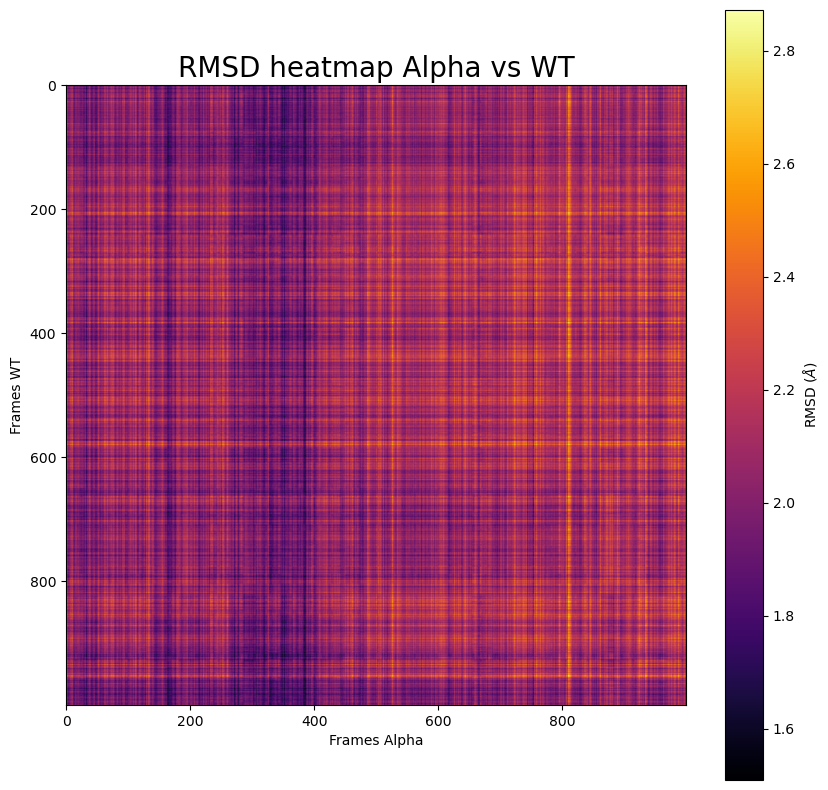

In [42]:
#Alpha vs wild type
#print(rmsd_map)
dim = math.ceil(5001/red_factor)
print("effective dimension is ", dim)
rmsd_map_A_WT = np.array(rmsd_map_A_WT).reshape((dim,dim))
plt.figure(figsize=((10,10)))
plt.title("RMSD heatmap Alpha vs WT", fontsize=20)
img = plt.imshow(rmsd_map_A_WT,cmap='inferno')
plt.colorbar(img,label=r'RMSD ($\AA$)');
plt.xlabel('Frames Alpha')
plt.ylabel('Frames WT')
img.figure.savefig('2DRMSD_Wild_Type_Alpha_tot')

effective dimension is  1000


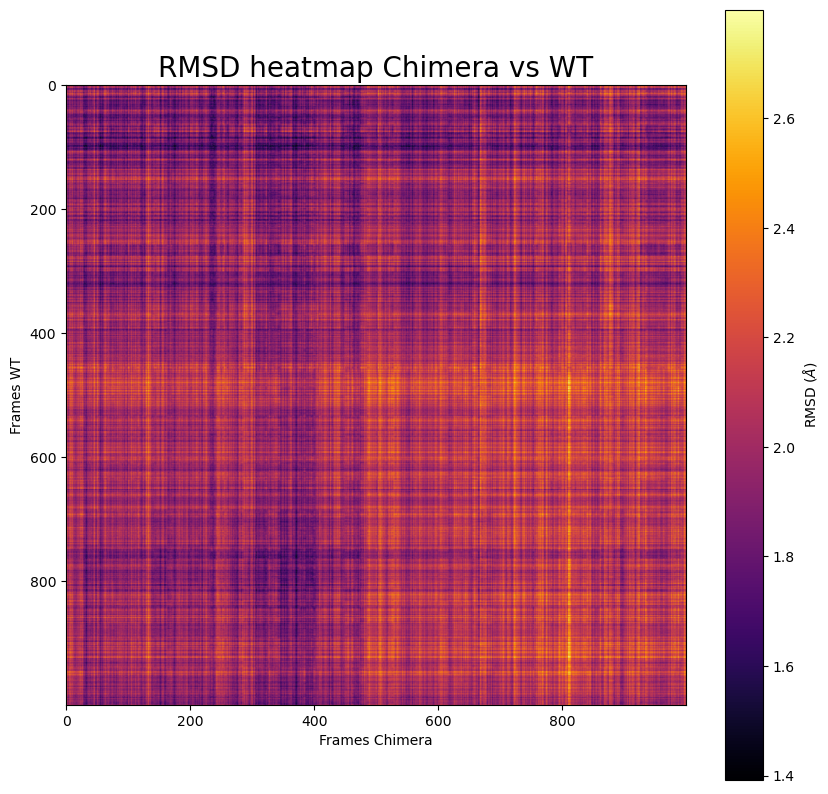

In [43]:
#Chimera vs wild type
#print(rmsd_map)
dim = math.ceil(5001/red_factor)
print("effective dimension is ", dim)
rmsd_map_C_WT = np.array(rmsd_map_C_WT).reshape((dim,dim))
plt.figure(figsize=((10,10)))
plt.title("RMSD heatmap Chimera vs WT", fontsize=20)
img = plt.imshow(rmsd_map_C_WT,cmap='inferno')
plt.colorbar(img,label=r'RMSD ($\AA$)');
plt.xlabel('Frames Chimera')
plt.ylabel('Frames WT')
img.figure.savefig('2DRMSD_Wild_Type_Chimera_tot')

In [ ]:
#Wild type vs itself
#print(rmsd_map)
dim = math.ceil(5001/red_factor)
print("effective dimension is ", dim)
rmsd_map_WT = np.array(rmsd_map_WT).reshape((dim,dim))
plt.figure(figsize=((10,10)))
plt.title("RMSD heatmap WT", fontsize=20)
img = plt.imshow(rmsd_map_WT,cmap='inferno')
plt.colorbar(img,label=r'RMSD ($\AA$)');
plt.xlabel('Frames')
plt.ylabel('Frames')
img.figure.savefig('2DRMSD_Wild_Type_tot')

In [ ]:
#Chimera vs itself
#print(rmsd_map)
dim = math.ceil(5001/red_factor)
print("effective dimension is ", dim)
rmsd_map_C = np.array(rmsd_map_C_C).reshape((dim,dim))
plt.figure(figsize=((10,10)))
plt.title("RMSD heatmap Chimera", fontsize=20)
img = plt.imshow(rmsd_map_C,cmap='inferno')
plt.colorbar(img,label=r'RMSD ($\AA$)');
plt.xlabel('Frames')
plt.ylabel('Frames')
img.figure.savefig('2DRMSD_Chimera_tot')

In [ ]:
#Alpha vs itself
#print(rmsd_map)
dim = math.ceil(5001/red_factor)
print("effective dimension is ", dim)
rmsd_map = np.array(rmsd_map).reshape((dim,dim))
plt.figure(figsize=((10,10)))
plt.title("RMSD heatmap Alpha", fontsize=20)
img = plt.imshow(rmsd_map,cmap='inferno')
plt.colorbar(img,label=r'RMSD ($\AA$)');
plt.xlabel('Frames')
plt.ylabel('Frames')
img.figure.savefig('2DRMSD_Alpha_tot')

effective dimension is  1000


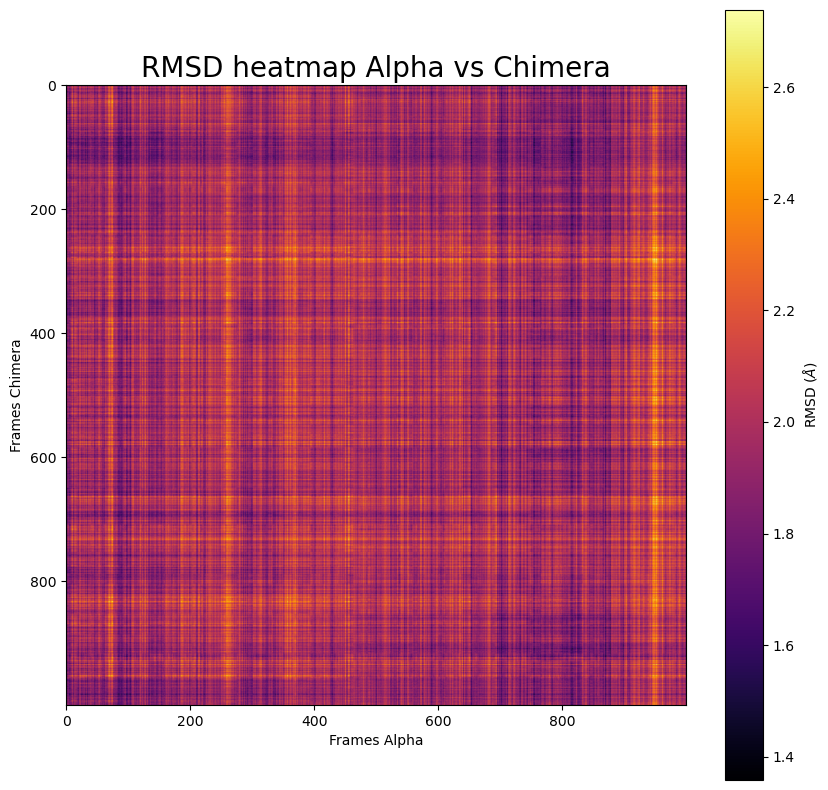

In [47]:
#Alpha vs Chimera
#print(rmsd_map)
dim = math.ceil(5001/red_factor)
print("effective dimension is ", dim)
rmsd_map_show = np.array(rmsd_map_A_C).reshape((dim,dim))
plt.figure(figsize=((10,10)))
plt.title("RMSD heatmap Alpha vs Chimera", fontsize=20)
img = plt.imshow(rmsd_map_show,cmap='inferno')
plt.colorbar(img,label=r'RMSD ($\AA$)');
plt.xlabel('Frames Alpha')
plt.ylabel('Frames Chimera')
img.figure.savefig('2DRMSD_Alpha_Chimera_tot')